<center><h1>Fine-tuning Gemma 2 for Spanish QA using SQUAD-es, evaluated on MLQA and XQuAD</h1></center>
<center><h2>Fine-tuning Results Analysis Notebook</h2></center>

This project fine-tunes **Gemma 2** (2B variant), a compact decoder-only LLM, for Spanish question-answering using **LoRA** (Low-Rank Adaptation), enabling training within local hardware constraints (16GB VRAM).  

The question we are looking to answer is: *can a small decoder-only model, that has been trained primarily in English, learn to perform Spanish extractive QA reasonably well with basic fine-tuning, despite architectural constraints?*  

In this notebook we will load the results of the fine-tuning experiments and evaluation runs logged into Weights & Biases.  

After loading the results, we will analyze them and justify the hyperparameters chosen, as well as the performance obtained with the final model in our test sets.

# Table of Contents

- [1. Setup](#1-setup)
- [2. Project Overview](#2-project-overview)
- [3. Trainer Implementation Technical Note](#3-trainer-implementation-technical-note)
- [4. mBERT Baseline Training](#4-mbert-baseline-training)
- [5. Gemma 2 Zero-Shot Evaluation](#5-gemma-2-zero-shot-evaluation)
- [6. Gemma 2 Fine-tuning](#6-gemma-2-fine-tuning)
    - [6.1. Baseline Configuration](#6-1-baseline-configuration)
    - [6.2. Learning Rate Experiment](#6-2-learning-rate-experiment)
    - [6.3. Target Modules Experiment](#6-3-target-modules-experiment)
    - [6.4. LoRA Rank & Alpha Experiment](#6-4-lora-rank-&-alpha-experiment)
    - [6.5. Final Model Training](#6-5-final-model-training)
- [7. Final Evaluation](#7-final-evaluation)
    - [7.1. SQuAD Val Set](#7-1-squad-val-set)
    - [7.2. MLQA Test Set](#7-2-mlqa-test-set)
    - [7.3. XQuAD Test Set](#7-3-xquad-test-set)
- [8. Conclusions](#8-conclusions)
- [9. Citations & References](#9-citations--references)

# 1. Setup

Here we will import all necessary libraries used during the execution of this notebook:

In [ ]:
# Standard library imports
import os
from pathlib import Path

# Third-party imports
import wandb

# Local imports
from analysis import plot_wandb_runs, get_wandb_best_values
from credentials import load_wandb_credentials

In [2]:
# Set project root directory as working directory for path consistency
os.chdir(Path('../').resolve())

In [3]:
# Load W&B credentials
api_key = load_wandb_credentials()

# Instantiate Weights and Biases API
api = wandb.Api(api_key=api_key)

# W&B Project Details
entity = "kev-hl-personal-team"
project = "gemma-2-spanish-qa"

# 2. Project Overview

**Task:**  
Extractive QA - Question answering where a context is provided that contains a span of text which is the answer.  
In this case, questions <u>always</u> have an answer.  

**Data:**  
Data with the same style and format as SQuAD 1.1 will be used (SQuAD 2.0 extends its content to questions with no answer, which is why it will not be used in this project).  
- **Training Data:** Train split of SQuAD 1.1 (45,995 samples), machine translated to Spanish, cleaned of translation artifacts by the translation authors, cleaned further during our own EDA process.
- **Validation Data:** Dev split of SQuAD 1.1 (5,774 samples), machine translated to Spanish, cleaned of translation artifacts by the translation authors, cleaned further during our own EDA process.
- **Test Data** (holdout, unseen)**:** MLQA Spanish subset (spanish context + spanish question variant, 5,253 samples), and XQuAD Spanish subset (1,190 samples). Both used without modification, only format changes to adapt to the standard SQuAD style.

_Note: During the data cleaning process, entries that were present on XQuAD (originally a subset of the SQuAD 1.1 dev set) were removed from our validation data._  

**Models:**  
- **Baseline:** **mBERT** was chosen as our baseline model. Being an encoder-only model, it is very well suited for extractive QA task. The QA head used is the implementation on the Hugging Face transformers library. Even though not SOTA, BERT variants still populate many high leaderboard positions on the SQuAD 1.1 rankings, and this multilingual variant should perform reasonably well on our spanish data.
- **Target model:** **Gemma 2** (2B variant) will be the model being fine-tuned for the task. It is a general purpose decoder only model, compact enough to be handled with a single GPU when using PEFT techniques. The model was pre-trained primarily in English, which means that while not being purposefully trained for multilingual capabilities (like its successor Gemma 3), there could be some Spanish present on its pre-training data.

**Evaluation metrics:**  
Matching the original SQuAD paper, we will be evaluating the models on F1 and Exact Match (EM).  
We will use the evaluation script from the *evaluate* library, which follows the logic of the original SQuAD evaluation script.  

**Hardware:**  
All experiments will be run locally, using a consumer grade GPU from Nvidia, model RTX 5060ti with 16GB of VRAM, on a system powered by a CPU Intel 14600K with 32GB DDR5 RAM.

**Objective:**  
Due to architectural differences, a decoder-only model (Gemma 2) with a generative approach is expected to not be able to match a model like mBERT, even though it is a significantly stronger model (~110M vs ~2B just in parameters). Specially on the strict EM, because a generative approach will score badly on a metric that asks for verbatim answers.

Our objective is not to find if it can beat mBERT, but rather to answer:
- Can Gemma 2 learn the task reasonably well?
- Is it capable of adapting to Spanish?  

And the mBERT baseline will be the frame of reference to answer these relative questions.

# 3 Trainer Implementation Technical Note

Gemma 2 training runs used SFTTrainer from the TRL library, while mBERT and all standalone evaluations used the standard HuggingFace Trainer. Although SFTTrainer inherits from Trainer, minor differences in how each handles the evaluation produce small numerical discrepancies in loss and metrics.

Example (same checkpoint, same settings, no answer grounding):
- SFTTrainer reports:   Eval loss 0.48, F1 56.73, EM 15.71
- Trainer reports:      Eval loss 0.42, F1 56.31, EM 15.47

**Impact on analysis:**
- Fine-tuning experiments (all SFTTrainer): fully comparable
- Final evaluation (all Trainer): fully comparable  
- Cross-trainer comparisons: not directly meaningful

Only instance of cross-trainer comparison:
mBERT baseline and zero-shot Gemma 2 evaluation are used as reference points at the start of fine-tuning, but never as decisive factors.

# 4. mBERT Baseline Training

This table summarizes the main training settings for the mBERT baseline.  

The complete configuration can be found in `configs/training/mbert_baseline.json`.

| Setting | Value |
|----------|---------|
| **Training** | |
| Epochs | 2 |
| Batch size | 128 |
| Gradient accumulation steps | 1 |
| Dtype | float32 |
| **Learning Rate** | |
| Initial LR | 3e-5 |
| Warmup | Linear, 10% of first epoch |
| Scheduler | Cosine |
| **Optimization** | |
| Optimizer | AdamW (Torch Fused) |
| Weight decay | 0.01 |
| Max grad norm | 1.0 |
| **Evaluation** | |
| Batch size | 64 |
| Frequency | Every ~10% of epoch |
| Checkpoint strategy | Best F1 score |

In [4]:
# W&B Run IDs:
run_id = ["itp7nl7e"]

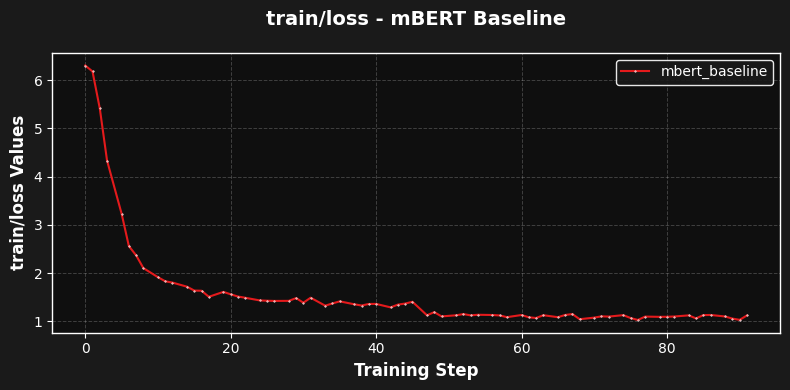

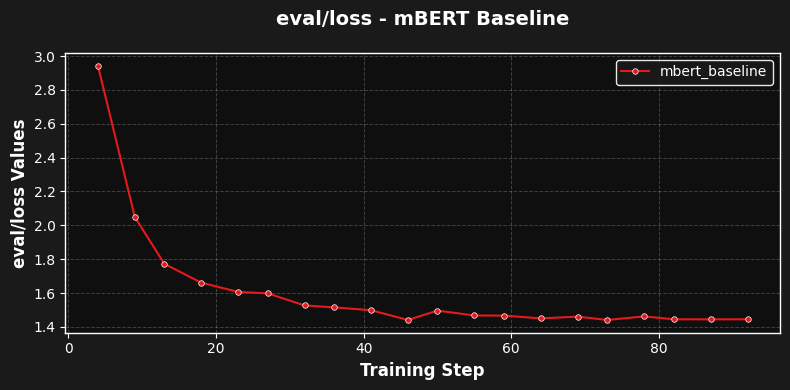

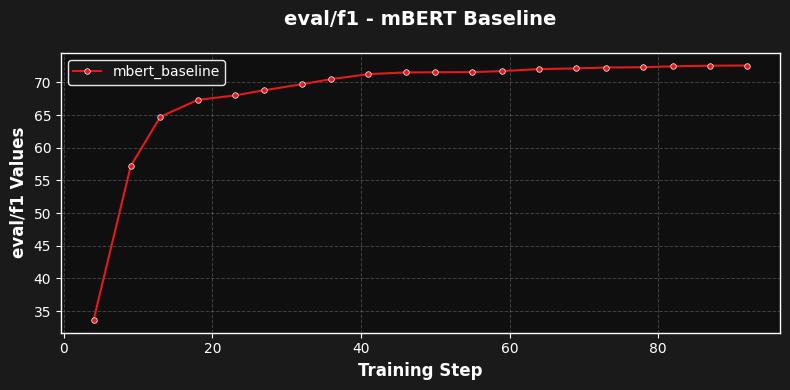

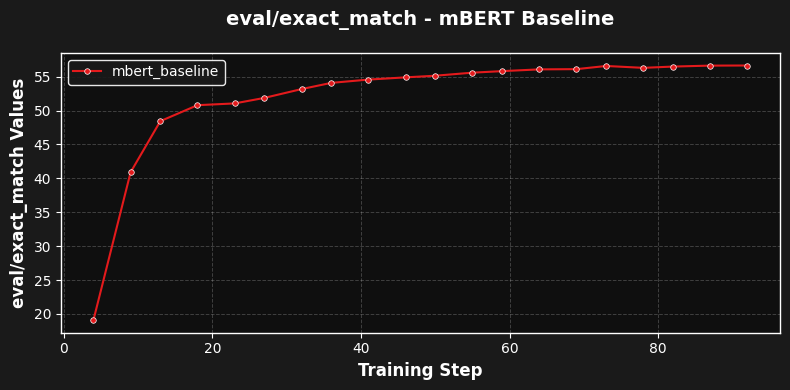

In [5]:
# Plot training curves for the runs
plot_wandb_runs(api, entity, project, 'mBERT Baseline', run_id)

In [6]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_id)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,mbert_baseline,1.444843,72.59788,56.650502


As we can see from the training curves, the model improves greatly during the first half of the first epoch, slowing down during the second half. The second epoch while bringing some improvement, it is minimal.  

On the best checkpoint we achieved an F1 score of 72.59 and an EM of 56.65, which will serve as our reference for a well performing model.  

The original authors of the SQuAD translation we used for training also fine-tuned mBERT to assess translation quality. While they did not publish their SQuAD scores, their results on MLQA and XQuAD (66/47 and 74/60 F1/EM respectively) suggest our baseline is performing as expected. We will be able to make a direct comparison when we evaluate our baseline on these benchmarks later.

# 5. Gemma 2 Zero-Shot Evaluation

This table summarizes the main evaluation settings used for the Gemma 2 2B zero-shot evaluation.   

The complete configuration can be found in `configs/eval/gemma2_zero_squad.json`.  

The evaluation was done directly with the pre-trained weights directly loaded from the Hugging Face Hub.

| Setting | Value |
|----------|---------|
| **Model** | |
| Dtype | bfloat16 |
| **Pre-processing** | |
| Max Sequence Length | 550 |
| **Evaluation** | |
| Batch size | 4 |

In [7]:
# W&B Run IDs:
run_id = ["ic0v5rco"]

In [8]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_id)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,gemma2_zero_eval_squad,2.731653,29.504685,0.225147


Surprisingly, the zero-shot evaluation shows that despite Gemma 2 not being purposefully trained in Spanish, it is still capable of understanding and generating related text. An F1 score of 29.5, while still very far from our mBERT baseline (~73), demonstrates that the generated answers were not complete random noise.  

Exact match, as expected, gets a near zero (0.23) value. This is reasonable, because even if the model generates coherent and relevant answers, verbatim matches would only occur with single-word answers.

# 6. Gemma 2 Fine-tuning

## 6.1 Default Configuration

> **NOTE:** Gemma 2 metrics reported during training can present small numerical variations compared with standalone evaluations, due to minor internal differences between the trainers used. All fine-tuning runs are comparable to each other; all final evaluation runs are comparable to each other. See technical note on section 3 for more details.

As previously explained, surpassing or even matching mBERT is improbable due to architectural differences. After training mBERT and zero-shot evaluating Gemma 2, the expected range of our scores becomes our frame of reference.

| Model | F1 | EM |
|----------|---------|---------|
| mBERT Baseline | 72.60 | 56.65 |
| Gemma 2 Zero-shot | 29.50 | 0.23 |

To train Gemma 2 (even the 2B variant) within GPU memory constraints, several measures are necessary:
- Load model in BF16 (weights, biases, buffers)
- Enable BF16 mixed precision training (activations and gradients)
- Enable full BF16 evaluation (activations and gradients)
- Keep optimizer states in full precision (unless OOM forces otherwise)
- Enable gradient checkpointing
- Use LoRA adapter for training

Also it is important to note that for faster iterations, due to our limited resources, we will do 1 epoch runs for all fine-tuning experiments.  
We will only extend training for the final model unless the training curves suggest that longer training is required for convergence.  

These are the default parameters used for fine-tuning.  
For each experiment, we will mention only the parameters that differ from these defaults

| Setting | Value |
|----------|---------|
| **Training** | |
| Epochs | 1 |
| Batch size | 4 |
| Gradient accumulation steps | 12 |
| Dtype | bfloat16 |
| **Learning Rate** | |
| Initial LR | 3e-5 |
| Warmup | Linear, 10% of first epoch |
| Scheduler | Cosine |
| **LoRA Config** | |
| Rank | 16 |
| Alpha | 16 |
| Dropout | 0.1 |
| Target modules | ["q_proj", "k_proj", "v_proj", "o_proj"] (attention layers)|
| **Optimization** | |
| Optimizer | AdamW (Torch Fused) |
| Weight decay | 0.01 |
| Max grad norm | 1.0 |
| **Evaluation** | |
| Batch size | 4 |
| Frequency | Every ~10% of epoch |
| Checkpoint strategy | Best F1 score |

## 6.2 Learning Rate Experiment

The first stage of our fine-tuning process is adjusting the learning rate.  

The complete configuration for each run can be found in `configs/training/`.  
Each JSON file follows the format: **gemma2_lrXeY_r16a16_tm4.json**  
Where lrXeY indicates the learning rate (e.g. lr1e4 = 1e-4), the minus sign is omitted for simplicity.

We initially considered a conventional range for LoRA fine-tuning:  
- 1e-5, 2e-5, 3e-5, 5e-5

However, as shown in the charts, larger learning rates demonstrated clear improvements.  
To find the stability ceiling, we extended the search to:
- 1e-5, 2e-5, 3e-5, 5e-5, 1e-4, 2e-4, 5e-4

In [9]:
# W&B Run IDs:
run_ids = [
    gemma2_lr1e5_r16a16_tm4 := "rccsw7qp",
    gemma2_lr2e5_r16a16_tm4 := "bqdach3y",
    gemma2_lr3e5_r16a16_tm4 := "7vd8d1qd",
    gemma2_lr5e5_r16a16_tm4 := "qt83zatk",
    gemma2_lr1e4_r16a16_tm4 := "uoablc04",
    gemma2_lr2e4_r16a16_tm4 := "t7woykrm",
    gemma2_lr5e4_r16a16_tm4 := "4xx3n9i0",
]
# Run aliases for better readability in plots:
aliases = {
    "gemma2_lr1e5_r16a16_tm4": "LR1e-5",
    "gemma2_lr2e5_r16a16_tm4": "LR2e-5",
    "gemma2_lr3e5_r16a16_tm4": "LR3e-5",
    "gemma2_lr5e5_r16a16_tm4": "LR5e-5",
    "gemma2_lr1e4_r16a16_tm4": "LR1e-4",
    "gemma2_lr2e4_r16a16_tm4": "LR2e-4",
    "gemma2_lr5e4_r16a16_tm4": "LR5e-4",
}

In [10]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head(10)

,run_name,eval/loss,eval/f1,eval/exact_match
0,LR2e-4,0.474730,56.634863,15.794943
1,LR1e-4,0.501882,56.423496,15.500520
2,LR5e-5,0.518796,56.038423,15.535158
3,LR5e-4,0.494504,55.896108,15.465882
4,LR3e-5,0.539191,55.771138,15.361967
5,LR2e-5,0.562344,55.607478,15.344648
6,LR1e-5,0.619106,55.029411,14.928992


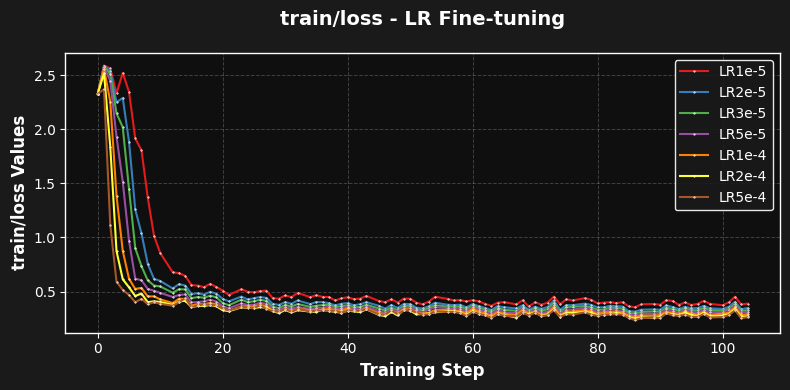

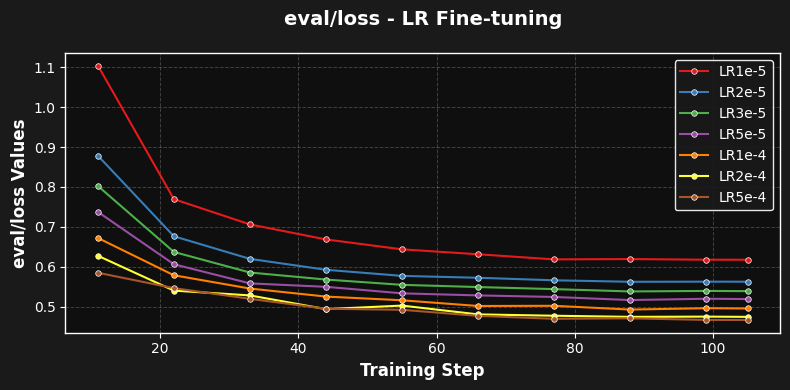

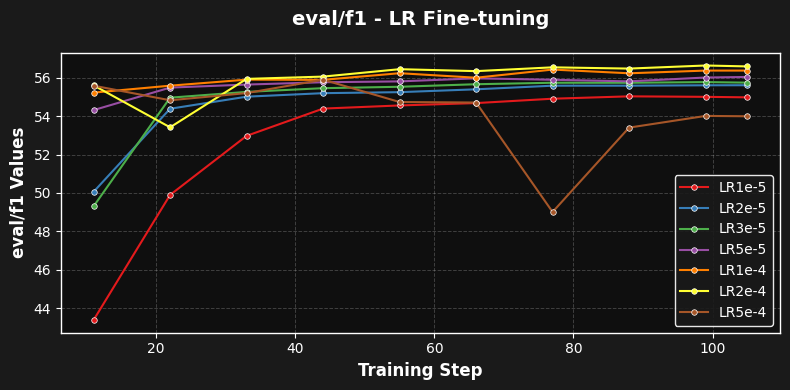

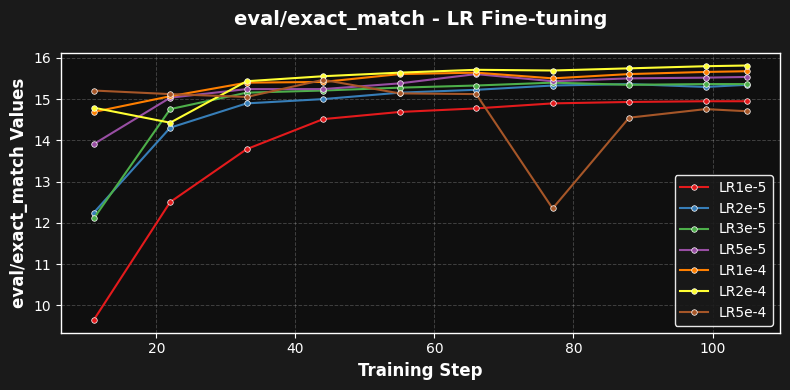

In [11]:
# Plot training curves for the runs
plot_wandb_runs(api, entity, project, 'LR Fine-tuning', run_ids, aliases)

All four initial runs (up to 5e-5) showed improvement with no signs of overfitting or train/eval loss divergence.

Since no instability appeared, we extended the search.

At 1e-4, the curves continued improving with stable values, justifying further extension to 2e-4.

The 2e-4 run produced the best results across all metrics (eval loss, F1, EM), but exhibited a divergence from the pattern at the second evaluation (20% of epoch). At this point, the monotonic improvement broke: F1 and EM crashed slightly before recovering fully within one evaluation cycle. The eval/loss curve also showed a distinct pattern—while still decreasing monotonically, the rate was inconsistent during the first half of the epoch 
compared to other runs. These signs suggested 2e-4 was at or near the upper stability boundary.

A final run at 5e-4 confirmed that higher LR values degrade performance. This run showed worse values overall than the top 3, broke the continuous improvement trend, and exhibited a training collapse mid-epoch with only partial recovery and worse final metrics.

**Conclusion:** Based on these results, 2e-4 was selected for optimal performance given the superior metrics However, given the signs seen of possible instability, 1e-4 will remain as our safe fallback if further experiments show stability issues.

## 6.3 Target Modules Experiment

So far we have targeted only the attention layers with LoRA, but general LoRA literature and guides often recommend targeting all linear layers, including MLPs. Both approaches have merit.

For instruction following, attention-only is recommended. While our task involves cross-lingual adaptation rather than pure format learning, they are conceptually similar.

However, for cross-lingual adaptation, MLP layers hold much of the linguistic knowledge, and targeting them could be beneficial.

This motivates our next experiment: comparing both approaches:  
- **Attention only:** ["q_proj", "k_proj", "v_proj", "o_proj"]
- **Attention + MLP:** ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

The complete configuration for each run can be found in `configs/training/`.  
Each JSON file follows the format: **gemma2_lr1e4_r16a16_tmX.json**  
Where tmX is either tm4 (4 target modules, attention only) or tm7 (7 target modules, attention + MLP).

In [12]:
# W&B Run IDs:
run_ids = [
    gemma2_lr1e4_r16a16_tm4 := "uoablc04",
    gemma2_lr2e4_r16a16_tm4 := "t7woykrm",
    gemma2_lr1e4_r16a16_tm7 := "3gd9qt0b",
    gemma2_lr2e4_r16a16_tm7 := "3jo2bj7h",
]
# Run aliases for better readability in plots:
aliases = {
    "gemma2_lr1e4_r16a16_tm4": "LR1e-4 TM4",
    "gemma2_lr2e4_r16a16_tm4": "LR2e-4 TM4",
    "gemma2_lr1e4_r16a16_tm7": "LR1e-4 TM7",
    "gemma2_lr2e4_r16a16_tm7": "LR2e-4 TM7",
}

In [13]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,LR2e-4 TM4,0.474730,56.634863,15.794943
1,LR1e-4 TM4,0.501882,56.423496,15.500520
2,LR1e-4 TM7,0.483271,56.382104,15.604434
3,LR2e-4 TM7,0.476984,56.109522,15.552477


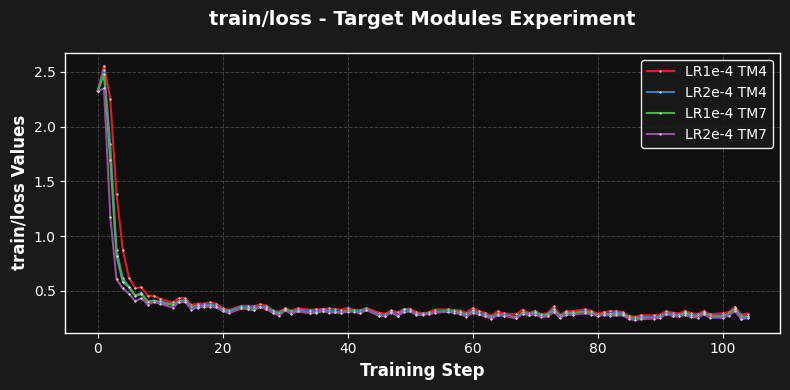

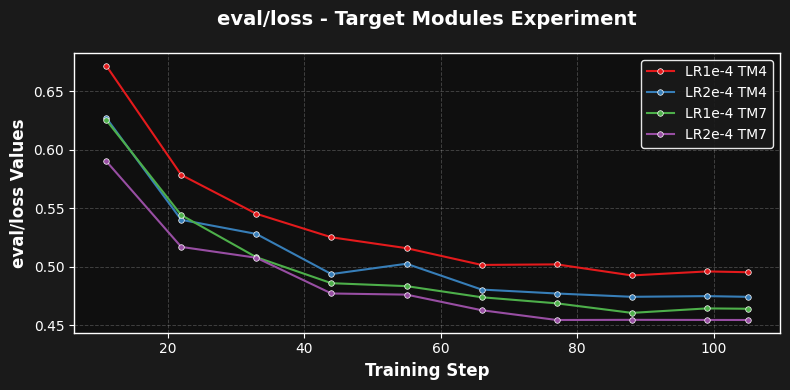

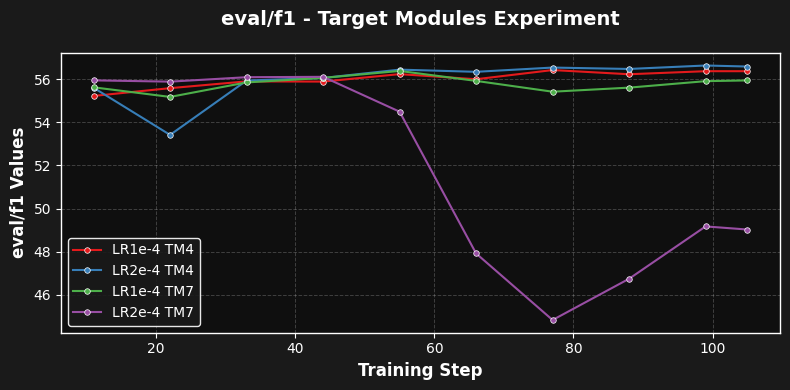

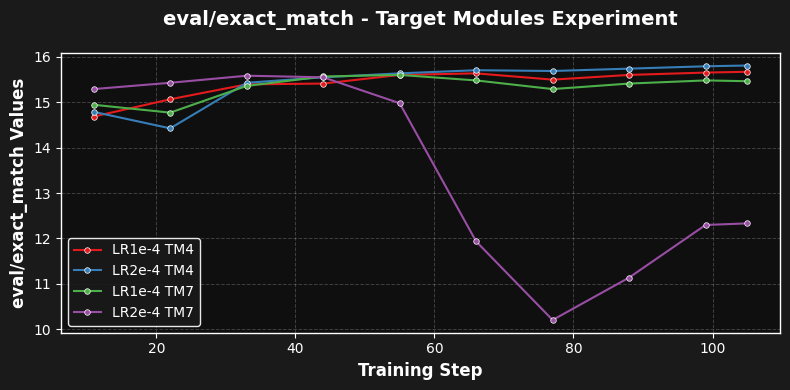

In [14]:
# Plot training curves for the runs
plot_wandb_runs(api, entity, project, 'Target Modules Experiment', run_ids, aliases)

First, we observed that our chosen LR, which showed signs of being near the stability limit, became unstable when adding extra target modules. Adding more parameters means more weights to update with the same LR, leading to larger cumulative changes in the model (bigger effective learning rate), and this increase was sufficient to push from barely stable to unstable.

We therefore repeated the attention+MLP experiment with 1e-4 for a fair comparison against the attention-only 1e-4 run.

Comparing both 1e-4 runs, performance is very similar, and the first half of the epoch shows no clear winner. However, the second half consistently favors attention-only in both F1 and EM.

**Conclusion:** Adding MLP layers increases parameters and decreases performance. Without clear advantage, we drop this approach.

However, the attention-only 2e-4 run remains the highest-scoring model (56.63 F1, 15.79 EM). Yet it occupies a fragile stability boundary. Notably, even the 1e-4 attention+MLP run shows early instability around 
20% of the epoch—the same point where 2e-4 attention-only faltered. This convergence of signals indicates 2e-4 is too close to its instability ceiling. The performance gain (+0.21 F1, +0.29 EM) does not justify the 
risk of corrupted experiments due to instability.

Therefore, we will continue fine-tuning with **learning rate 1e-4 and attention-only target modules**.

## 6.4 LoRA Rank & Alpha Experiment

So far, we have seen that while we improved the model, the differences have been minor. This final fine-tuning stage explores whether different LoRA parameters meaningfully influence model behavior for this task.

The complete configuration for each run can be found in `configs/training/`.  
Each JSON file follows the format: **gemma2_lr1e4_rXaY_tm4.json**  
Where X is the LoRA rank and Y is the LoRA alpha. Some runs enable rsLoRA, indicated with "rs" at the end (e.g., r32a32rs = rank 32, alpha 32, rsLoRA enabled).

We compare the following configurations:  

- **Rank 16, Alpha 16:** Default, middle ground
- **Rank 8, Alpha 16:** Conservative option, closest to original LoRA paper style (ratio=2)
- **Rank 32, Alpha 32, rsLoRA:** More expressive approach
- **Rank 64, Alpha 64, rsLoRA:** Most expressive approach

In [15]:
# W&B Run IDs:
run_ids = [
    gemma2_lr1e4_r16a16_tm4 := "uoablc04",
    gemma2_lr1e4_r8a16_tm4 := "4q45r83m",
    gemma2_lr1e4_r32a32rs_tm4 := "aljuyreq",
    gemma2_lr1e4_r64a64rs_tm4 := "0ve1xxvp",
]
# Run aliases for better readability in plots:
aliases = {
    "gemma2_lr1e4_r16a16_tm4": "r16a16",
    "gemma2_lr1e4_r8a16_tm4": "r8a16",
    "gemma2_lr1e4_r32a32rs_tm4": "r32a32rs",
    "gemma2_lr1e4_r64a64rs_tm4": "r64a64rs",
}

In [16]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,r16a16,0.501882,56.423496,15.500520
1,r32a32rs,0.492573,56.083574,15.413924
2,r8a16,0.524815,55.823441,15.413924
3,r64a64rs,0.582769,55.652489,15.240734


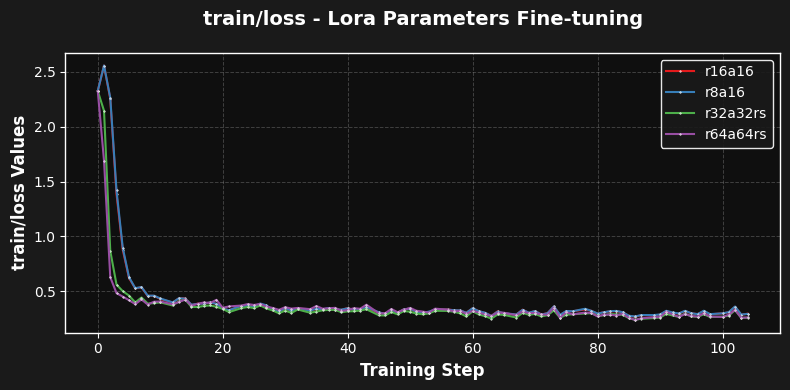

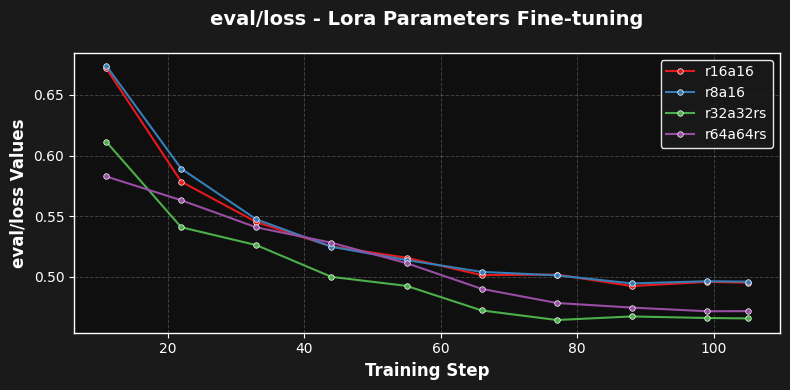

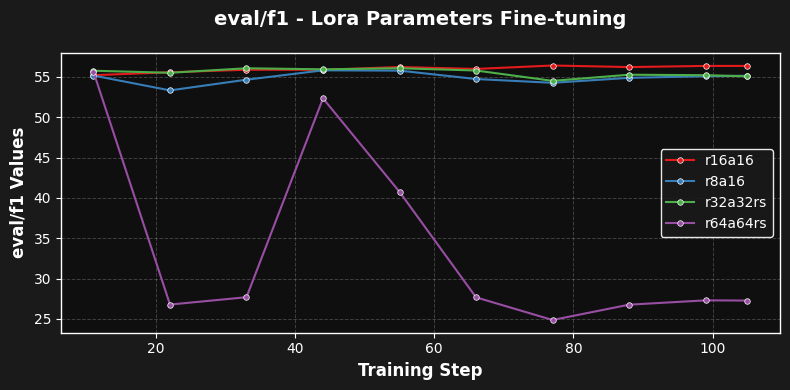

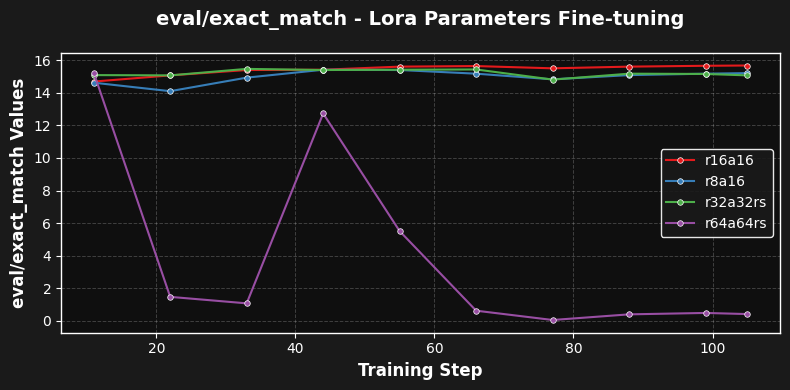

In [17]:
# Plot training curves for the runs
plot_wandb_runs(api, entity, project, 'Lora Parameters Fine-tuning', run_ids, aliases)

Differences between runs are minimal. The rank 16, alpha 16 default configuration consistently outperforms other options, though by a narrow margin. Larger configurations achieved lower loss values (train and eval) 
but worse eval metrics (our primary criteria).

Notably, the largest adapter (rank 64, alpha 64) introduced enough parameters to push 1e-4 into the unstable range, mirroring what happened when we added MLP target modules to 2e-4. However, since the middle option (rank 32, alpha 32) underperformed our default, there is no reason to retry rank 64 with a lower learning rate.

**Conclusion:** Rank 16, Alpha 16 with standard LoRA scaling is our optimal configuration.

## 6.5 Final Model Training

After our fine-tuning experiments, we have identified our optimal configuration.  
During the 1-epoch runs, we observed no overfitting signs. While generally the second half of each epoch showed stable values, extending to 2 epochs carries little risk and may yield additional performance gains.  

As this is our final training run, we summarize the main parameters.  
The complete configuration can be found in `configs/training/gemma2_final_model.json`.

| Setting | Value |
|----------|---------|
| **Training** | |
| Epochs | 2 |
| Batch size | 4 |
| Gradient accumulation steps | 12 |
| Dtype | bfloat16 |
| **Learning Rate** | |
| Initial LR | 1e-4 |
| Warmup | Linear, 10% of first epoch |
| Scheduler | Cosine |
| **LoRA Config** | |
| Rank | 16 |
| Alpha | 16 |
| Dropout | 0.1 |
| Target modules | ["q_proj", "k_proj", "v_proj", "o_proj"] (attention layers)|
| **Optimization** | |
| Optimizer | AdamW (Torch Fused) |
| Weight decay | 0.01 |
| Max grad norm | 1.0 |
| **Evaluation** | |
| Batch size | 4 |
| Frequency | Every ~10% of epoch |
| Checkpoint strategy | Best F1 score |



In [18]:
# W&B Run IDs:
run_id = ["yesktu7k"]

In [19]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_id)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,gemma2_final_model,0.482405,56.727119,15.708348


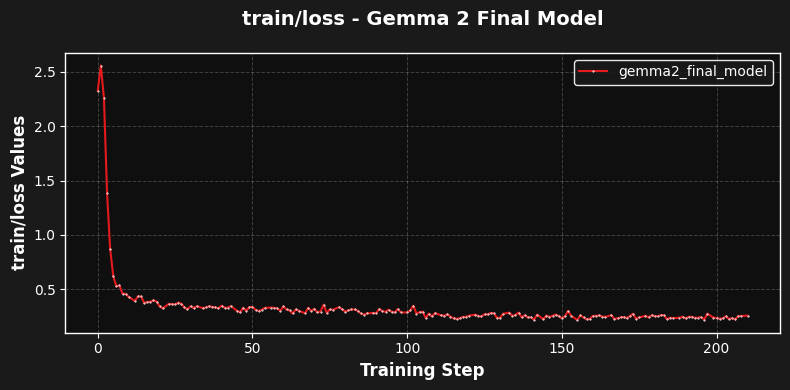

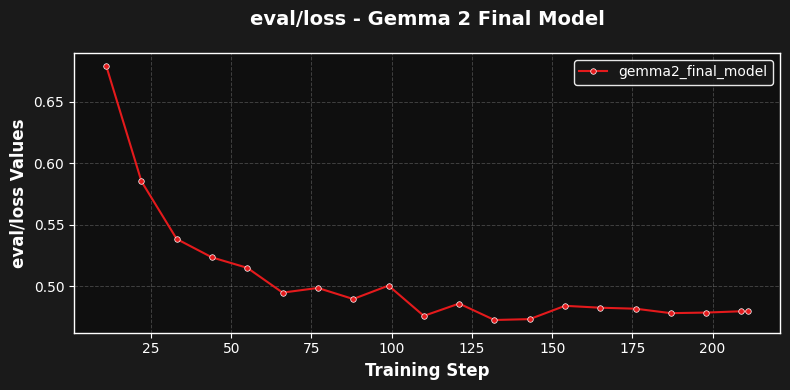

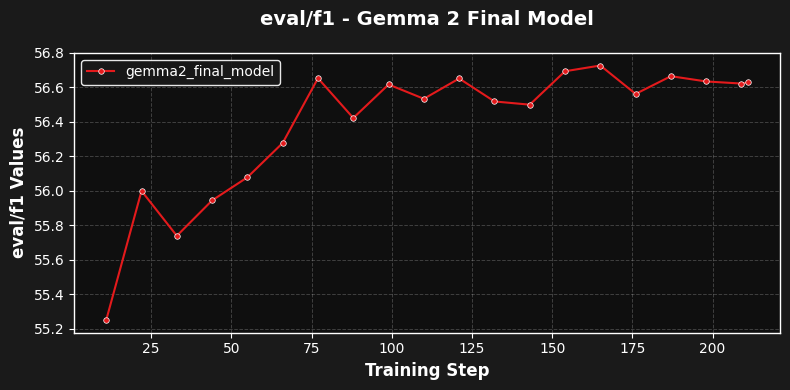

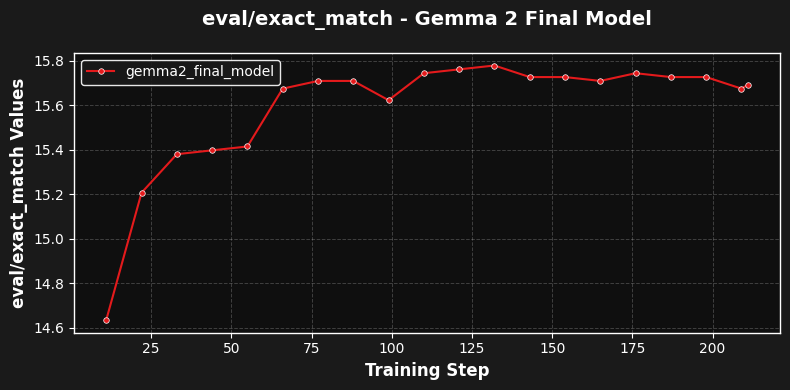

In [20]:
# Plot training curves for the runs
plot_wandb_runs(api, entity, project, 'Gemma 2 Final Model', run_id)

We observed modest improvement with no signs of overfitting.  
Given the small gains (0.31 F1, 0.21 EM) and the fact that the best epoch 2 checkpoint occurred around 60-70% of the epoch rather than near the end, a 3-epoch run is unlikely to yield meaningful improvements.

| Model | F1 | EM |
|--------|----|----|
| Best checkpoint, epoch 1 | 56.42 | 15.50 |
| Best checkpoint, epoch 2 | 56.73 | 15.71 |

## 6.6 Answer Grounding Post-processing

> **NOTE:** Gemma 2 metrics reported during training can present small numerical variations compared with standalone evaluations, due to minor internal differences between the trainers used. All fine-tuning runs are comparable to each other; all final evaluation runs are comparable to each other. See technical note on section 3 for more details.

Due to Gemma 2's generative approach, it is penalized by standard extractive QA metrics, particularly EM, when answers are correct but worded differently.

To mitigate this, we implement answer grounding: matching generated answers to context spans using fuzzy matching (rapidfuzz partial_ratio_alignment). When a match exceeds 80% token similarity, the prediction is replaced with the actual context span.

**Example 1: Perfect Match (100%)**

Question: "Where is Google's headquarters located?"

Context: "...Google's headquarters is in Mountain View, California..."

Generated answer: "Mountain View, California"

Matched span: "Mountain View, California" (100% match)

Result: Prediction unchanged.

---

**Example 2: Close Match (≥80%, replaced)**

Question: "What is the capital of France?"

Context: "...Paris, the capital city of France, is known for..."

Generated answer: "the capital city of France is Paris"

Matched span: "Paris, the capital city of France" (85% match, above threshold)

Result: Prediction replaced with matched span: "Paris, the capital city of France"

---

**Example 3: Poor Match (<80%, unchanged)**

Question: "Who wrote Romeo and Juliet?"

Context: "...Shakespeare wrote many plays including Romeo and Juliet..."

Generated answer: "the author of Romeo and Juliet"

Best match found: "Romeo and Juliet" (42% match, below threshold)

Result: Prediction unchanged (uses generated answer).

In [21]:
# W&B Run IDs:
run_ids = [
    gemma2_final_eval_squad := "7larjoco",
    gemma2_final_eval_squad_grounded := "nxufu7sn",
]
# Run aliases for better readability in plots:
aliases = {
    "gemma2_final_eval_squad": "Not-Grounded",
    "gemma2_final_eval_squad_grounded": "Grounded",
}

In [22]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,Grounded,0.419636,56.533381,15.569796
1,Not-Grounded,0.419636,56.310775,15.465882


While modest, the relative improvement rivals the gains from the entire fine-tuning process.

The limited improvement stems partly from the SQuAD evaluation metrics script (from the evaluate library), which already handles normalization issues (e.g., missing articles like "the"). However, answer grounding remains valuable for inference, where such normalization is not applied.

More aggressive thresholds could yield higher scores, but risk masking incorrect answers as correct.

**Conclusion:** Given the improvement and the low cost and risk, answer grounding will be applied to all generative model evaluations in the final comparison.

# 7. Final Evaluation

Final evaluations compare 3 models:  

- **mBERT Baseline:** HuggingFace QA linear head, trained on SQuAD Train
- **Gemma 2 Zero-shot:** Pre-trained weights from HuggingFace Hub, with answer grounding
- **Gemma 2 Final Model:** Fine-tuned weights trained on SQuAD Train, with answer grounding

Answer grounding uses an 80% similarity threshold across all cases.  
All evaluations use standalone evaluation scripts.  

Evaluation configuration files can be found in `configs/eval`.

## 7.1 SQuAD Val Set

> **NOTE:** Gemma 2 metrics reported during training can present small numerical variations compared with standalone evaluations, due to minor internal differences between the trainers used. All fine-tuning runs are comparable to each other; all final evaluation runs are comparable to each other. See technical note on section 3 for more details.

Before evaluating on unseen data (MLQA and XQuAD test sets), we first evaluate on the SQuAD validation set.

In [23]:
# W&B Run IDs:
run_ids = [
    mbert_baseline_eval_squad := "ecvjox2l",
    gemma2_zero_eval_squad_grounded := "ril3fygu",
    gemma2_final_eval_squad_grounded := "nxufu7sn",
]
# Run aliases for better readability in plots:
aliases = {
    "mbert_baseline_eval_squad": "mBERT Baseline",
    "gemma2_zero_eval_squad_grounded": "G2 Zero-Shot",
    "gemma2_final_eval_squad_grounded": "G2 Final Model",
}

In [24]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,mBERT Baseline,1.444824,72.600189,56.650502
1,G2 Final Model,0.419636,56.533381,15.569796
2,G2 Zero-Shot,2.731653,31.605767,0.900589


Before moving forward, it is important to note that mBERT baseline scores appear low compared to the SQuAD 1.1 leaderboard because we used machine-translated Spanish data, not English. After cleaning by translation authors 
and our own EDA, this dataset contains roughly half the samples of the original SQuAD. Using less data of lower quality (machine-translated) means scores are not directly comparable to the leaderboard.

Regarding Gemma 2 2B, as expected, the compact decoder-only model underperforms the smaller, simpler encoder-only mBERT on extractive QA.  

However, Gemma 2 demonstrates promising capabilities: despite being trained primarily in English, it generates context-related text zero-shot (F1 31.61).  
After fine-tuning, F1 improves to 56.53—still below mBERT's 72.60, but 
showing strong reasoning and cross-lingual adaptation.


Exact Match remains poor (15.57), as expected. While the model generates reasonable answers, verbatim extraction is limited to very short spans, a fundamental constraint of the generative approach.

## 7.2 MLQA Test Set

The first test set is MLQA, using the Spanish subset (Spanish context and Spanish question).

In [25]:
# W&B Run IDs:
run_ids = [
    mbert_baseline_eval_mlqa := "jwcotg43",
    gemma2_zero_eval_mlqa_grounded := "0bgbx44w",
    gemma2_final_eval_mlqa_grounded := "0p2d83ba",
]
# Run aliases for better readability in plots:
aliases = {
    "mbert_baseline_eval_mlqa": "mBERT Baseline",
    "gemma2_zero_eval_mlqa_grounded": "G2 Zero-Shot",
    "gemma2_final_eval_mlqa_grounded": "G2 Final Model",
}

In [26]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,mBERT Baseline,2.420643,64.311577,42.509042
1,G2 Final Model,0.625544,61.226139,14.239482
2,G2 Zero-Shot,2.549262,39.705791,1.218351


On unseen data, mBERT baseline shows expected performance degradation compared to validation, but still achieves reasonable scores. For context: the MLQA paper reports 64.3 F1 for mBERT on the Spanish subset (zero-shot 
from English training, not directly comparable). The SQuAD translation authors achieved 65.5 F1 and 47.2 EM on MLQA after training on their translation—directly comparable to our baseline. Our mBERT performs as expected and serves as a valid reference point.

Gemma 2 zero-shot shows improvement over SQuAD validation (F1 39.71 vs 31.61), likely because MLQA uses higher-quality data rather than machine translation. EM remains near zero, as expected.

After fine-tuning, Gemma 2 achieves competitive F1 scores (61.23), nearly matching mBERT (64.31, −3.1 F1 difference). EM remains poor (14.24), a fundamental constraint of the generative approach.

## 7.3 XQuAD Test Set

The second test set is XQuAD, using the Spanish subset (Spanish context and Spanish question).

_Note: While XQuAD is originally a subset of the SQuAD dev set, we removed XQuAD entries from our validation data to prevent bias. XQuAD itself remains untouched._

In [27]:
# W&B Run IDs:
run_ids = [
    mbert_baseline_eval_xquad := "x8l1iddp",
    gemma2_zero_eval_xquad_grounded := "2ya18zjp",
    gemma2_final_eval_xquad_grounded := "m11h8txm",
]
# Run aliases for better readability in plots:
aliases = {
    "mbert_baseline_eval_xquad": "mBERT Baseline",
    "gemma2_zero_eval_xquad_grounded": "G2 Zero-Shot",
    "gemma2_final_eval_xquad_grounded": "G2 Final Model",
}

In [28]:
# Fetch and display values of best checkpoints for each run
results = get_wandb_best_values(api, entity, project, run_ids, aliases)
results.head()

,run_name,eval/loss,eval/f1,eval/exact_match
0,mBERT Baseline,1.291876,73.528915,55.714286
1,G2 Final Model,0.324611,64.009131,14.789916
2,G2 Zero-Shot,2.246259,36.604095,0.840336


mBERT baseline achieves similar scores on XQuAD as on SQuAD validation (73.53 vs 72.60 F1), which is expected, as XQuAD is a subset of the SQuAD dev set, so the data distributions and content are similar. The professionally translated text has minimal impact on performance. Like with MLQA, we can use the scores obtained on mBERT by the SQuAD translation authors, which in the case of XQuAD they achieved 73.8 F1 and 59.5 EM, which again proves that our baseline is performing on expected levels.  

Gemma 2 zero-shot again benefits from high-quality translation, achieving better F1 score than on validation (36.60 vs 31.61). This aligns with our observations: the model generalizes well to MLQA, and XQuAD combines 
training-like data with high-quality translation, producing a competitive fine-tuned F1 score (64.01). EM remains near zero without fine-tuning and poor afterward (14.79), consistent with previous results.

# 8. Conclusions

**Task Feasibility**

This project investigated whether Gemma 2 2B, a compact decoder-only model pre-trained primarily in English, could be effectively fine-tuned for extractive question answering on Spanish data.

Despite significant architectural differences from the task-optimized mBERT baseline, Gemma 2 demonstrates that the task is learnable with modest computational resources.

---

**Key Findings**

**Base model capability:** Zero-shot evaluation showed that Gemma 2's pre-trained weights are already capable of generating answers to some extent, achieving F1 scores in the 30-40 range despite no explicit training on this 
task or language.

**Fine-tuning effectiveness:** Through systematic hyperparameter exploration (learning rate, target modules, LoRA rank/alpha), we identified an optimal configuration achieving 56.5 F1 on the SQuAD validation set—a 25-point gain 
from zero-shot (31.6 F1). However, differences between stable configurations were consistently marginal, suggesting the model benefits primarily from format learning (exposure to new data) rather than hyperparameter optimization.

**Cross-lingual adaptation:** Despite no explicit multilingual training, Gemma 2 successfully adapted to Spanish, particularly on high-quality translated data (MLQA, XQuAD), reaching competitive F1 scores within 3-9 points of mBERT across test sets.

**Generative vs. extractive trade-off:** As expected, the generative approach excels at semantic understanding (competitive F1 scores, good generalization) but struggles with exact matching (EM ~15 vs. mBERT's 56). Answer grounding via fuzzy matching provided modest improvements (+0.21 F1, +0.22 EM) and represents a practical mitigation for inference, particularly valuable when the SQuAD evaluation script's normalization is unavailable.

---

**Zero-shot Improvement**

| Dataset | Zero-shot F1 | Fine-tuned F1 | Improvement |
|---------|----------|-----------|-----|
| SQuAD Val | 31.61 | 56.53 | +24.9 |
| MLQA | 39.71 | 61.23 | +21.5 |
| XQuAD | 36.60 | 64.01 | +27.4 |

---

**Performance Summary**

| Dataset | mBERT F1 | Gemma 2 F1 | Gap |
|---------|----------|-----------|-----|
| SQuAD Val | 72.60 | 56.53 | −16.1 |
| MLQA | 64.31 | 61.23 | −3.1 |
| XQuAD | 73.53 | 64.01 | −9.5 |

---

**Future Directions**

- **Larger Gemma variants:** Evaluate Gemma 2 9B or larger models to assess performance ceiling.
- **Multilingual pre-training:** Test Gemma 3 or other multilingual LLMs to isolate the impact of cross-lingual pre-training.
- **Data quality:** Investigate the impact of high-quality human translations vs. machine translation on both models.
- **Linguistic diversity:** Extend Gemma 2 evaluation to languages with extreme linguistic distance from English, testing adaptation limits beyond readily available Romance languages.

---

**Final Statement**

This work demonstrates that compact decoder-only LLMs can be effectively fine-tuned for extractive QA on cross-lingual data, performing at a reasonable level without task-specific pre-training.

While not viable as a replacement for task-specialized models like mBERT or XLM-RoBERTa—which remain superior and more resource-efficient for training and inference—this project validates a key strength of large general LLMs: 
their versatility, reasoning capability, and generalization ability. Gemma 2 2B proves that even compact decoder-only models can leverage these strengths for downstream tasks beyond their training distribution.

# 9. Citations and References

**Models:**
- Gemma 2 2B: [Hugging Face Model Page](https://huggingface.co/google/gemma-2-2b)
- mBERT: [Hugging Face Model Page](https://huggingface.co/google-bert/bert-base-multilingual-cased)

**Datasets:**
- SQuAD (original): [SQuAD: 100,000+ Questions for Machine Comprehension of Text](https://arxiv.org/abs/1606.05250) (Rajpurkar, Zhang, Lopyrev, Liang. EMNLP 2016)
- SQuAD (translation): [Automatic Spanish Translation of the SQuAD Dataset for Multilingual Question Answering](https://arxiv.org/abs/1912.05200) (Carrino, Costa-jussà, Fonollosa. arXiv 2019)
- MLQA: [MLQA: Evaluating Cross-lingual Extractive Question Answering](https://arxiv.org/abs/1910.07475) (Lewis, Oguz, Rinott, Riedel, Schwenk. arXiv 2019)
- XQuAD: [On the cross-lingual transferability of monolingual representations](https://arxiv.org/abs/1910.11856) (Artetxe, Ruder, Yogatama. arXiv 2019)

**LoRA Literature and Resources:**  
- LoRA Original Paper: [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685) (Hu et al. ICLR 2022)
- [A Rank Stabilization Scaling Factor for Fine-Tuning with LoRA](https://arxiv.org/abs/2312.03732) (Kalajdzievski. arXiv 2023)
- [Rank-Stabilized LoRA: Unlocking the Potential of LoRA Fine-Tuning](https://huggingface.co/blog/damjan-k/rslora) (Kalajdzievski. Hugging Face blog post 2024)
- Unsloth.ai Documentation: [LoRA fine-tuning Hyperparameters Guide](https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide)
- ML FAQ: [How do rank and alpha affect LoRA behavior in practice?](https://sebastianraschka.com/faq/docs/lora-rank-alpha.html) (Raschka, blog post)

**Kaggle competition (inspiration):**
- [Google Gemma Global Communication Comp Announcement](https://discuss.ai.google.dev/t/join-the-competition-unlock-global-communication-with-gemma/47814)
- [Kaggle Gemma Language Tuning Comp](https://www.kaggle.com/competitions/gemma-language-tuning)